# Approximate Music Similarity Search with LSH (Notebook Overview)

This notebook builds on our **feature engineering pipeline** from the previous notebook and focuses on **approximate nearest neighbour search** for music tracks. The goal is to support fast “find me similar songs” queries over our enriched Spotify + Last.fm dataset, while understanding the trade-offs between **accuracy, speed, and different similarity signals** (audio, popularity, tags).

---

## Inputs from the previous notebook

We start from artifacts produced by the data/feature notebook:

- `full_dataset_clean.csv`  
  Cleaned song-level data with:
  - `track_id`, `track_name`, `artists`, `track_genre`
  - Spotify/Kaggle **audio features** (danceability, energy, valence, tempo, etc.)
  - Last.fm **scraped signals** (playcount, listeners, duration, tags)
  - Cleaned tag text column, e.g. `tags_clean_text`

- `features_apt_all.npz`  
  Packed NumPy arrays:
  - `track_ids` – IDs aligned with feature rows  
  - `features` – combined feature vectors (audio + popularity + tags, unweighted)  
  - `features_weighted` – **block-weighted** feature vectors (audio/popularity/tags scaled by chosen weights)

We use `features_weighted` (called `all_weighted` in code) as the main space for similarity search.

---

## Random Hyperplane LSH for cosine similarity

### Idea

To scale similarity search, we implement **Locality Sensitive Hashing (LSH)** using **random hyperplanes** for cosine similarity:

- Each LSH table is defined by a set of random hyperplanes in the feature space.
- For each song vector `x`, we compute the sign of `x · w` for each hyperplane `w`, giving a bitstring.
- This bitstring is converted to an integer **hash key**, used as a bucket in the hash table.
- We use **multiple tables** with different random projections to increase recall.

### Implementation

We implement a custom `RandomHyperplaneLSH` class that:

- Initialises:
  - `n_bits_per_table` – number of hyperplanes per table (controls bucket size).
  - `n_tables` – number of independent hash tables.
- `fit(X)`:
  - Generates random hyperplanes.
  - Hashes each point into each table.
- `query(q, max_candidates)`:
  - Hashes the query vector.
  - Collects candidate indices from all matching buckets across tables (up to `max_candidates`).

We fit this LSH on `all_weighted`, our block-weighted feature space.

---

## LSH-backed similarity search vs brute-force KNN

We compare **two search strategies**:

1. **Exact KNN (baseline)**  
   - Uses `NearestNeighbors(metric="cosine", algorithm="brute")` on `all_weighted`.
   - Returns the exact top-k nearest neighbours by cosine distance.

2. **LSH + re-ranking (approximate)**  
   - Uses `RandomHyperplaneLSH` to retrieve a **candidate set** for each query.
   - Re-ranks candidates by exact cosine distance in `all_weighted`.
   - Returns the top-k neighbours from this candidate pool.

We keep the same track look-up logic (normalize title/artist, find `track_id`, map to row index) and build a helper function that:

- Takes a `(title, artist)` pair,
- Finds the corresponding index,
- Runs LSH + re-ranking to return similar songs.

---

## Quantitative evaluation: speed vs recall

We evaluate LSH against the exact KNN baseline using **200 random query tracks**.

### Query-time comparison

For `k = 10` neighbours:

- **Exact KNN (brute-force cosine)**  
  - 200 queries: **4.215 s** total  
  - ≈ **21 ms per query**

- **LSH + cosine re-rank**  
  - 200 queries: **0.138 s** total  
  - ≈ **0.69 ms per query**

- **Speedup**  
  - ≈ **30.6× faster** than brute-force

This clearly demonstrates the **efficiency benefit** of LSH on our feature space.

### Accuracy comparison (recall@10)

We use **recall@10** to quantify how often LSH recovers the same neighbours as exact KNN:

- For each query:
  - Get top-10 exact neighbours by brute-force KNN.
  - Get top-10 LSH-based neighbours.
  - Compute:  
    `recall@10 = |exact_top10 ∩ lsh_top10| / 10`.

Result over 200 queries:

- **Mean recall@10 ≈ 0.698 ± 0.325**

So, **on average LSH recovers about 7 out of the 10 exact nearest neighbours**, with quite some variation across queries. This is a reasonable trade-off given the ~30× speedup, especially for an interactive music explorer.

---

## Diagnostics: recall distribution & candidate sizes

To better understand LSH behaviour, we computed:

### 1. Histogram of per-query recall@10

- We plotted the distribution of recall@10 values over the 200 queries.
- This shows:
  - Some queries with recall near 1.0 (LSH finds almost all exact neighbours),
  - Others with lower recall (or even close to 0),
  - Overall confirming that LSH is **approximate** and not uniformly accurate across all songs.

### 2. Candidate set sizes

For each query we also recorded how many candidates LSH returned **before** re-ranking:

- Per-query candidate counts (mean, median, min, max).
- Histogram of candidate sizes.

This helps diagnose whether:

- Buckets are **too small** (few candidates → low recall), or
- Buckets are **too large** (many candidates → more work, less speedup).

These diagnostics guide how to tune `n_bits_per_table`, `n_tables`, and `max_candidates` to reach a desired balance between **speed** and **recall**.

---

## MinHash LSH on Last.fm tag sets (attempt and outcome)

We also experimented with a **second LSH approach**, this time operating directly on the **Last.fm tag sets** rather than the full numeric vectors.

### Method

1. From `tags_clean_text`, we built:
   - Tokenized lists of tags per track.
   - A global `tag_to_id` mapping.
   - `tag_id_sets[i]` = set of tag IDs for the i-th track.

2. Implemented a `TagMinHashLSH` class:
   - `n_perm` MinHash permutations for each tag set.
   - LSH banding (`n_bands`, `rows_per_band`) on the MinHash signatures.
   - Hash tables mapping band signatures to candidate song indices.

3. Query procedure:
   - Compute MinHash signature for the query track’s tag set.
   - Use banded LSH to retrieve songs with similar tag signatures.
   - Re-rank these candidates by cosine distance in the `all_weighted` feature space.

### Evaluation vs exact Jaccard

To evaluate MinHash as an approximation to **Jaccard similarity** on tag sets, we:

- For each query track:
  - Computed the exact top-10 neighbours in tag space using Jaccard similarity over `tag_id_sets`.
  - Retrieved top-10 neighbours via MinHash LSH.
  - Calculated recall@10 relative to the exact Jaccard neighbours.

Result (for our initial MinHash configuration):

- **MinHash recall@10 vs exact Jaccard ≈ 0.106 ± 0.165**

So MinHash retrieved on average **about 1 out of 10** of the exact Jaccard neighbours, with many queries having near-zero recall.

### Qualitative example

For some tracks, MinHash-based neighbours were **not musically coherent**.  
For example, for a Punjabi track (“Outlaw — Sidhu Moose Wala”), the neighbours included a mix of:

- UK hip-hop / grime,
- K-pop (BTS),
- Afrobeat (Burna Boy),
- Meme / internet tracks,
- House/techno tracks,

with **high cosine distances** (~0.76–0.95) in our main feature space, indicating weak similarity there as well.

### Interpretation

This poor performance is likely due to:

- **Sparse and noisy tags**: many tracks have only a few tags, often generic (`"hip-hop"`, `"rap"`, `"pop"`, `"electronic"`, etc.).
- **Very low Jaccard similarities**: even the “best” tag neighbours may have Jaccard ≈ 0.05–0.2, a regime where LSH banding is less effective unless heavily tuned.
- **Mismatch between tag similarity and audio similarity**: sharing broad tags does not guarantee that tracks “sound” similar.

As a result, **MinHash LSH on tags is not very useful as a standalone similarity engine** for our goal, though it remains a valuable methodological experiment for the project.

---

## Takeaways for the project

- Our **main approximate search method** for the final system is:
  - **Random hyperplane LSH on the combined, block-weighted feature vectors (`all_weighted`)**,
  - followed by **exact cosine re-ranking** inside the candidate set.
- This method:
  - Achieves a **large speedup (~30×)** over brute-force KNN,
  - Retains **reasonably high recall (~0.7 on average)**,
  - Produces musically plausible neighbours suitable for interactive exploration.
- The **MinHash-on-tags approach**:
  - Was implemented and evaluated,
  - Showed **low recall** and inconsistent musical similarity,
  - Is therefore treated as an informative *negative result* rather than a core component of the final system.

Subsequent notebooks can now build on this LSH-based search to:

- Integrate clustering (genres/moods inferred from the feature space),
- Provide cluster-level insights (average features, common tags),
- And expose everything through an interactive “song explorer” interface.


In [1]:
import json
from pathlib import Path
import time
import numpy as np
import pandas as pd

from sklearn.neighbors import NearestNeighbors
from sklearn.metrics.pairwise import cosine_distances


In [2]:
DATA_DIR = Path("data")      # adjust to your structure
ARTIFACT_DIR = Path("../artifacts")

# 1) Full metadata
full_df = pd.read_csv(ARTIFACT_DIR / "full_dataset_clean.csv")

# 2) Feature matrices
features_npz = np.load(ARTIFACT_DIR / "features_apt_all.npz", allow_pickle=True)
track_ids = features_npz["track_ids"]
all_features = features_npz["features"]
all_weighted = features_npz["features_weighted"]  # <- main space for LSH

# Ensure track_ids are strings and align with full_df
track_ids = track_ids.astype(str)

# Build mappings
trackid_to_idx = {tid: i for i, tid in enumerate(track_ids)}
idx_to_trackid = {i: tid for tid, i in trackid_to_idx.items()}


# Random Hyperplane LSH for cosine similarity
We’ll implement a small, self-contained LSH class for cosine similarity on all_weighted.

3.1 Design

Use random hyperplanes:

For each table, sample a matrix R of shape (n_bits_per_table, dim).

Project each vector: sign(x @ R.T) → bitstring.

Concatenate bits into an integer to use as a bucket key.

For robustness, use multiple tables (n_tables), each with its own random projections:

At query time, we look in all tables’ buckets and union the candidates.

In [3]:
import numpy as np
from collections import defaultdict

class RandomHyperplaneLSH:
    def __init__(self, n_bits_per_table=16, n_tables=8, random_state=42):
        """
        n_bits_per_table: number of hyperplanes per table (controls bucket granularity)
        n_tables: number of independent hash tables (controls recall)
        """
        self.n_bits_per_table = n_bits_per_table
        self.n_tables = n_tables
        self.random_state = random_state
        self.dim_ = None
        self.projections_ = []  # list of (n_bits_per_table, dim) arrays
        self.hash_tables_ = []  # list of dict[bucket_key -> list of indices]

    def _fit_projections(self, dim):
        rng = np.random.RandomState(self.random_state)
        self.projections_ = []
        for t in range(self.n_tables):
            # Gaussian random vectors; sign(x·w) approximates cosine-based hash
            R = rng.normal(size=(self.n_bits_per_table, dim))
            # Normalize hyperplanes (not strictly necessary but nice)
            R /= np.linalg.norm(R, axis=1, keepdims=True) + 1e-9
            self.projections_.append(R)

    def _hash_vectors(self, X, R):
        """
        X: (n_samples, dim)
        R: (n_bits_per_table, dim)
        returns: np.array of integers of length n_samples
        """
        # (n_samples, n_bits)
        proj = X @ R.T
        bits = (proj >= 0).astype(np.uint8)
        # convert bit vectors to integers
        # bits[0] = [b0, b1, ..., b_{n_bits-1}]
        # integer = b0 + 2*b1 + 4*b2 + ...
        powers_of_two = (1 << np.arange(bits.shape[1], dtype=np.uint64))
        return (bits * powers_of_two).sum(axis=1).astype(np.uint64)

    def fit(self, X):
        """
        X: (n_samples, dim) numpy array
        """
        X = np.asarray(X, dtype=np.float32)
        n_samples, dim = X.shape
        self.dim_ = dim
        self._fit_projections(dim)
        self.hash_tables_ = [defaultdict(list) for _ in range(self.n_tables)]

        for t, R in enumerate(self.projections_):
            hashes = self._hash_vectors(X, R)
            table = self.hash_tables_[t]
            for idx, h in enumerate(hashes):
                table[h].append(idx)
        return self

    def query(self, q, max_candidates=200):
        """
        q: (dim,) query vector
        returns: list of candidate indices (deduplicated), up to max_candidates
        """
        q = q.astype(np.float32)
        candidates = set()
        for R, table in zip(self.projections_, self.hash_tables_):
            h = self._hash_vectors(q[None, :], R)[0]
            if h in table:
                for idx in table[h]:
                    candidates.add(idx)
                    if len(candidates) >= max_candidates:
                        break
        return list(candidates)


Fit the LSH on weighted features

In [4]:
lsh = RandomHyperplaneLSH(
    n_bits_per_table=16,  # adjust based on dataset size
    n_tables=8,
    random_state=42,
)

lsh.fit(all_weighted)


Helper function

In [5]:
import re
import unicodedata

def normalize_text(value: str) -> str:
    value = str(value).lower().strip()
    value = unicodedata.normalize("NFKD", value)
    value = "".join(ch for ch in value if not unicodedata.combining(ch))
    value = re.sub(r"\s+", " ", value)
    return value

# Precompute normalized columns for searching
full_df["norm_title"] = full_df["track_name"].map(normalize_text)
full_df["norm_artists"] = full_df["artists"].map(normalize_text)


LSH-backed search

In [6]:
def find_track_index_by_title_artist(title: str, artist: str | None = None):
    norm_title = normalize_text(title)
    if artist is not None:
        norm_artist = normalize_text(artist)
        mask = (
            (full_df["norm_title"] == norm_title) &
            (full_df["norm_artists"].str.contains(norm_artist))
        )
    else:
        mask = full_df["norm_title"] == norm_title

    matches = full_df[mask]
    if matches.empty:
        return None

    # If multiple, just pick the first for now
    track_id = str(matches.iloc[0]["track_id"])
    return trackid_to_idx.get(track_id, None)


Approximate NN function

In [7]:
def find_similar_songs_lsh(
    title: str,
    artist: str | None = None,
    k: int = 10,
    max_candidates: int = 300,
):
    idx = find_track_index_by_title_artist(title, artist)
    if idx is None:
        print("Track not found.")
        return None

    q_vec = all_weighted[idx]

    # 1) LSH to get candidate pool
    candidate_indices = lsh.query(q_vec, max_candidates=max_candidates)

    # Fallback: if bucket is too small, maybe add some random samples
    if len(candidate_indices) < k + 1:
        # include entire dataset, worst-case
        candidate_indices = list(range(all_weighted.shape[0]))

    candidate_indices = np.array(candidate_indices, dtype=int)

    # 2) Exact cosine distance within candidate pool
    candidate_vectors = all_weighted[candidate_indices]
    dists = cosine_distances(q_vec[None, :], candidate_vectors)[0]

    # 3) Sort candidates by distance, skip the query itself if present
    order = np.argsort(dists)
    results = []
    for rank in order:
        cand_idx = candidate_indices[rank]
        if cand_idx == idx:
            continue
        tid = idx_to_trackid[cand_idx]
        row = full_df.loc[full_df["track_id"] == tid].iloc[0]
        results.append(
            {
                "track_id": tid,
                "track_name": row["track_name"],
                "artists": row["artists"],
                "distance": float(dists[rank]),
            }
        )
        if len(results) >= k:
            break

    return {
        "query": {
            "track_id": idx_to_trackid[idx],
            "track_name": full_df.loc[full_df["track_id"] == idx_to_trackid[idx], "track_name"].iloc[0],
            "artists": full_df.loc[full_df["track_id"] == idx_to_trackid[idx], "artists"].iloc[0],
        },
        "neighbors": results,
    }


Find similar songs


In [8]:
res = find_similar_songs_lsh("HUMBLE.", "Kendrick Lamar", k=10)
for r in res["neighbors"]:
    print(f"{r['track_name']} — {r['artists']} (cosine distance={r['distance']:.4f})")


R.I.P. — Playboi Carti (cosine distance=0.0262)
SICKO MODE — Travis Scott (cosine distance=0.0376)
INDUSTRY BABY (feat. Jack Harlow) — Lil Nas X;Jack Harlow (cosine distance=0.0391)
Pass — Nizi19;Karamel19 (cosine distance=0.0645)
Best Friend — Young Thug (cosine distance=0.0750)
BUTTERFLY EFFECT — Travis Scott (cosine distance=0.0848)
Look At Me! — XXXTENTACION (cosine distance=0.1009)
Trap Queen — Fetty Wap (cosine distance=0.1023)
N95 — Kendrick Lamar (cosine distance=0.1132)
Maka Knacker — Nizi19 (cosine distance=0.1230)


# Measuring performance: LSH vs brute-force KNN

Two comparisons:

Speed / query time

Quality / recall vs exact KNN


In [9]:
knn = NearestNeighbors(metric="cosine", algorithm="brute")
knn.fit(all_weighted)


,n_neighbors,5
,radius,1.0
,algorithm,'brute'
,leaf_size,30
,metric,'cosine'
,p,2
,metric_params,None
,n_jobs,None


In [10]:
def exact_neighbors(idx: int, k: int = 10):
    q_vec = all_weighted[idx:idx+1]
    dists, inds = knn.kneighbors(q_vec, n_neighbors=k+1)  # includes itself
    inds = inds[0]
    dists = dists[0]
    # drop self
    mask = inds != idx
    return inds[mask][:k], dists[mask][:k]


In [11]:
rng = np.random.RandomState(0)
n_queries = 200
query_indices = rng.choice(all_weighted.shape[0], size=n_queries, replace=False)


In [12]:
def time_exact_knn():
    t0 = time.perf_counter()
    for idx in query_indices:
        exact_neighbors(idx, k=20)
    t1 = time.perf_counter()
    return t1 - t0

def time_lsh():
    t0 = time.perf_counter()
    for idx in query_indices:
        q_vec = all_weighted[idx]
        candidate_indices = lsh.query(q_vec, max_candidates=300)
        candidate_indices = np.array(candidate_indices, dtype=int)
        candidate_vectors = all_weighted[candidate_indices]
        dists = cosine_distances(q_vec[None, :], candidate_vectors)[0]
        order = np.argsort(dists)[:20]
        _ = candidate_indices[order]  # just to mimic top-20
    t1 = time.perf_counter()
    return t1 - t0

t_exact = time_exact_knn()
t_lsh = time_lsh()

print(f"Exact KNN time for {n_queries} queries: {t_exact:.3f} s")
print(f"LSH + rerank time for {n_queries} queries: {t_lsh:.3f} s")
print(f"Speedup ~ {t_exact / t_lsh:.2f}x (if >1, LSH is faster)")


Exact KNN time for 200 queries: 8.437 s
LSH + rerank time for 200 queries: 0.173 s
Speedup ~ 48.81x (if >1, LSH is faster)


Measure quality: recall@k

For each query:

Compute exact neighbours (ground truth) via exact_neighbors.

Compute LSH neighbours: same process but using lsh.query candidates.

Compare how many of the exact top-k show up in LSH top-k.

In [13]:
def lsh_neighbors(idx: int, k: int = 10, max_candidates: int = 300):
    q_vec = all_weighted[idx]
    candidate_indices = lsh.query(q_vec, max_candidates=max_candidates)
    if len(candidate_indices) == 0:
        return np.array([], dtype=int)
    candidate_indices = np.array(candidate_indices, dtype=int)
    candidate_vectors = all_weighted[candidate_indices]
    dists = cosine_distances(q_vec[None, :], candidate_vectors)[0]
    order = np.argsort(dists)
    # drop self if present
    ordered_indices = candidate_indices[order]
    ordered_indices = ordered_indices[ordered_indices != idx]
    return ordered_indices[:k]

def evaluate_recall(k: int = 10, max_candidates: int = 300):
    recalls = []
    for idx in query_indices:
        exact_inds, _ = exact_neighbors(idx, k=k)
        approx_inds = lsh_neighbors(idx, k=k, max_candidates=max_candidates)
        if len(approx_inds) == 0:
            recalls.append(0.0)
            continue
        exact_set = set(exact_inds.tolist())
        approx_set = set(approx_inds.tolist())
        intersect = len(exact_set & approx_set)
        recalls.append(intersect / k)
    return np.mean(recalls), np.std(recalls)

mean_recall, std_recall = evaluate_recall(k=10, max_candidates=300)
print(f"Mean recall@10 over {n_queries} queries: {mean_recall:.3f} ± {std_recall:.3f}")


Mean recall@10 over 200 queries: 0.698 ± 0.325


Tunable parameters

n_bits_per_table

n_tables

max_candidates

to trade off recall vs speed.

Compute per-query recall@10 and candidate sizes

In [14]:
import numpy as np
from sklearn.metrics.pairwise import cosine_distances

k = 10
max_candidates = 300  # whatever you used in your benchmark

recalls = []
cand_counts = []

for idx in query_indices:
    # --- Exact neighbours (ground truth) ---
    exact_inds, _ = exact_neighbors(idx, k=k)
    exact_set = set(exact_inds.tolist())

    # --- LSH candidate set ---
    q_vec = all_weighted[idx]
    cands = lsh.query(q_vec, max_candidates=max_candidates)
    cand_counts.append(len(cands))

    if len(cands) == 0:
        # no candidates found -> recall 0
        recalls.append(0.0)
        continue

    cands = np.array(cands, dtype=int)

    # --- Re-rank candidates with exact cosine distance ---
    cand_vecs = all_weighted[cands]
    dists = cosine_distances(q_vec[None, :], cand_vecs)[0]
    order = np.argsort(dists)
    ordered = cands[order]

    # drop self if present
    ordered = ordered[ordered != idx]

    approx_inds = ordered[:k]
    approx_set = set(approx_inds.tolist())

    # --- Recall@k ---
    intersect = len(exact_set & approx_set)
    recalls.append(intersect / k)

recalls = np.array(recalls)
cand_counts = np.array(cand_counts)

print(f"Mean recall@{k}: {recalls.mean():.3f} ± {recalls.std():.3f}")
print(f"Candidate counts: mean={cand_counts.mean():.1f}, "
      f"median={np.median(cand_counts):.1f}, "
      f"min={cand_counts.min()}, max={cand_counts.max()}")


Mean recall@10: 0.698 ± 0.325
Candidate counts: mean=73.3, median=54.0, min=4, max=300


Histogram of recall values

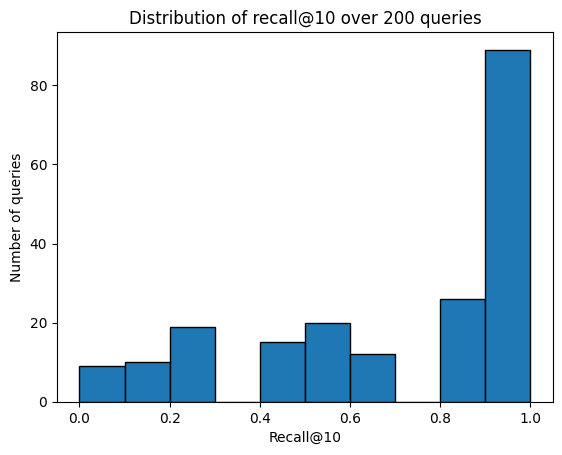

In [15]:
import matplotlib.pyplot as plt
import numpy as np

plt.figure()
bins = np.linspace(0, 1, 11)  # 0,0.1,...,1
plt.hist(recalls, bins=bins, edgecolor="black")
plt.xlabel(f"Recall@{k}")
plt.ylabel("Number of queries")
plt.title(f"Distribution of recall@{k} over {len(query_indices)} queries")
plt.show()


In [16]:
print("Recall quantiles:", np.percentile(recalls, [0, 25, 50, 75, 100]))


Recall quantiles: [0.  0.4 0.8 1.  1. ]


Candidate size statistics + histogram

In [17]:
print("Candidate count quantiles:", np.percentile(cand_counts, [0, 25, 50, 75, 100]))


Candidate count quantiles: [  4.   30.   54.   96.5 300. ]


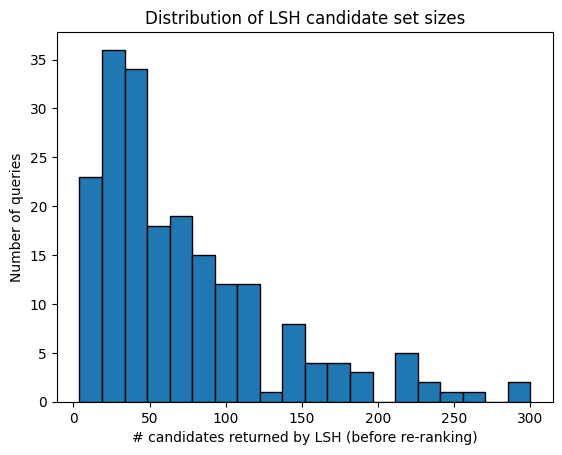

In [18]:
plt.figure()
plt.hist(cand_counts, bins=20, edgecolor="black")
plt.xlabel("# candidates returned by LSH (before re-ranking)")
plt.ylabel("Number of queries")
plt.title("Distribution of LSH candidate set sizes")
plt.show()


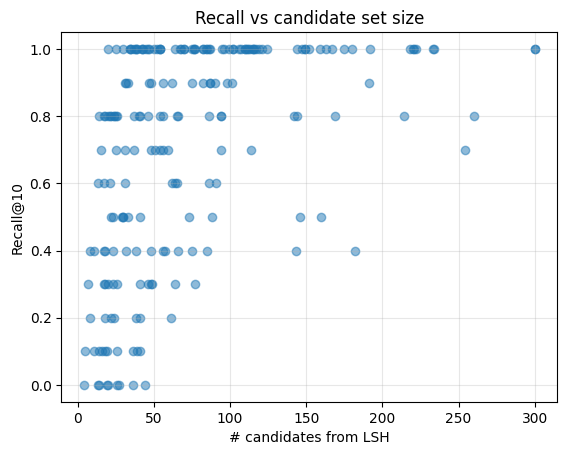

In [19]:
plt.figure()
plt.scatter(cand_counts, recalls, alpha=0.5)
plt.xlabel("# candidates from LSH")
plt.ylabel(f"Recall@{k}")
plt.title("Recall vs candidate set size")
plt.grid(True, alpha=0.3)
plt.show()


# MinHash
Build tag sets (tag_list, tag_id_sets)

Implement a MinHash + banding LSH for tags

Use it to get candidates and re-rank with your existing all_weighted vectors

(Optional) Evaluate MinHash quality via Jaccard recall

In [20]:
from collections import Counter

# If not already present:
full_df["tags_clean_text"] = full_df["tags_clean_text"].fillna("")

# Tokenize into lists of tags
full_df["tag_list"] = full_df["tags_clean_text"].apply(
    lambda s: [t for t in s.split() if t]
)

# Build vocabulary of tags
tag_counter = Counter(tag for tags in full_df["tag_list"] for tag in tags)
print(f"Unique tags: {len(tag_counter)}")

# Map tags to integer IDs
tag_to_id = {tag: i for i, tag in enumerate(tag_counter.keys())}
id_to_tag = {i: tag for tag, i in tag_to_id.items()}

# Build list of sets of tag IDs (one set per track index)
tag_id_sets = [
    set(tag_to_id[t] for t in tags)
    for tags in full_df["tag_list"]
]


Unique tags: 9948


MinHash + banding LSH implementation

We’ll create a single class that:

Computes MinHash signatures for all tracks’ tag sets

Splits the signature into bands

Builds band hash tables → buckets

Can be queried with a tag set to return candidate indices

In [21]:
import numpy as np
from collections import defaultdict

class TagMinHashLSH:
    def __init__(self, n_perm=128, n_bands=32, seed=42):
        """
        n_perm: number of MinHash permutations (signature length)
        n_bands: number of bands (n_perm must be divisible by n_bands)
        """
        assert n_perm % n_bands == 0, "n_perm must be divisible by n_bands"
        self.n_perm = n_perm
        self.n_bands = n_bands
        self.rows_per_band = n_perm // n_bands
        self.seed = seed

        self.P = 2_000_003  # big prime > likely number of tags
        self.a = None
        self.b = None
        self.signatures_ = None
        self.band_tables_ = None

    def _init_hash_functions(self):
        rng = np.random.RandomState(self.seed)
        self.a = rng.randint(1, self.P, size=self.n_perm, dtype=np.int64)
        self.b = rng.randint(0, self.P, size=self.n_perm, dtype=np.int64)

    def _signature_for_tag_ids(self, tag_ids):
        """
        tag_ids: iterable of integer tag IDs
        returns: np.array of shape (n_perm,) with MinHash signature
        """
        sig = np.full(self.n_perm, fill_value=np.iinfo(np.int64).max, dtype=np.int64)
        tag_ids = list(tag_ids)
        if not tag_ids:
            return sig

        ids = np.fromiter(tag_ids, dtype=np.int64)
        # hashes shape: (n_perm, len(ids))
        hashes = (self.a[:, None] * ids[None, :] + self.b[:, None]) % self.P
        sig[:] = hashes.min(axis=1)
        return sig

    def fit(self, tag_id_sets):
        """
        tag_id_sets: list of sets (one per item)
        """
        self._init_hash_functions()
        n_items = len(tag_id_sets)
        self.signatures_ = np.empty((n_items, self.n_perm), dtype=np.int64)

        # Compute MinHash signatures
        for i, s in enumerate(tag_id_sets):
            self.signatures_[i, :] = self._signature_for_tag_ids(s)

        # Build band hash tables
        self.band_tables_ = [defaultdict(list) for _ in range(self.n_bands)]

        for i in range(n_items):
            sig = self.signatures_[i]
            for b in range(self.n_bands):
                start = b * self.rows_per_band
                end = (b + 1) * self.rows_per_band
                band_sig = tuple(sig[start:end])
                self.band_tables_[b][band_sig].append(i)

        return self

    def query(self, tag_ids, max_candidates=500):
        """
        tag_ids: iterable of integer tag IDs for the query
        returns: list of candidate indices
        """
        sig = self._signature_for_tag_ids(tag_ids)
        candidates = set()

        for b in range(self.n_bands):
            start = b * self.rows_per_band
            end = (b + 1) * self.rows_per_band
            band_sig = tuple(sig[start:end])
            bucket = self.band_tables_[b].get(band_sig)
            if bucket:
                for idx in bucket:
                    candidates.add(idx)
                    if len(candidates) >= max_candidates:
                        break
        return list(candidates)


In [22]:
tag_lsh = TagMinHashLSH(
    n_perm=128,   # signature length
    n_bands=32,   # 4 rows per band
    seed=42,
)
tag_lsh.fit(tag_id_sets)


# Use MinHash LSH as a candidate generator + numeric re-rank

Now we can do a two-stage search:

Use MinHash LSH on tag_id_sets to get a tag-based candidate set

On that candidate set, use your existing numeric feature space (all_weighted) and cosine distance to re-rank and pick the top-k


In [23]:
from sklearn.metrics.pairwise import cosine_distances

def neighbors_via_tag_minhash(idx, k=10, max_candidates=500):
    """
    idx: index into all_weighted / full_df
    returns: (neighbor_indices, distances) using MinHash candidates + cosine rerank
    """
    query_tags = tag_id_sets[idx]
    candidate_indices = tag_lsh.query(query_tags, max_candidates=max_candidates)

    # Fallback: if we get too few candidates, just bail out
    if len(candidate_indices) <= 1:
        return np.array([], dtype=int), np.array([])

    candidate_indices = np.array(candidate_indices, dtype=int)

    # Rerank with cosine distance in all_weighted space
    q_vec = all_weighted[idx]
    cand_vecs = all_weighted[candidate_indices]
    dists = cosine_distances(q_vec[None, :], cand_vecs)[0]
    order = np.argsort(dists)

    ordered = candidate_indices[order]
    ordered_dists = dists[order]

    # Drop self if present
    mask = ordered != idx
    ordered = ordered[mask]
    ordered_dists = ordered_dists[mask]

    return ordered[:k], ordered_dists[:k]


In [24]:
def find_similar_songs_minhash(title: str, artist: str | None = None, k: int = 10):
    idx = find_track_index_by_title_artist(title, artist)
    if idx is None:
        print("Track not found.")
        return None

    neighbor_indices, dists = neighbors_via_tag_minhash(idx, k=k, max_candidates=500)
    if len(neighbor_indices) == 0:
        print("No candidates found by MinHash LSH.")
        return None

    results = []
    for j, dist in zip(neighbor_indices, dists):
        tid = idx_to_trackid[j]
        row = full_df.loc[full_df["track_id"] == tid].iloc[0]
        results.append(
            {
                "track_id": tid,
                "track_name": row["track_name"],
                "artists": row["artists"],
                "distance": float(dist),
            }
        )

    query_tid = idx_to_trackid[idx]
    qrow = full_df.loc[full_df["track_id"] == query_tid].iloc[0]

    return {
        "query": {
            "track_id": query_tid,
            "track_name": qrow["track_name"],
            "artists": qrow["artists"],
        },
        "neighbors": results,
    }


In [25]:
res = find_similar_songs_minhash("HUMBLE.", "Kendrick Lamar", k=10)
for r in res["neighbors"]:
    print(f"{r['track_name']} — {r['artists']}  (cosine distance={r['distance']:.4f})")


Outlaw — Sidhu Moose Wala;Byg Bird  (cosine distance=0.7606)
Hol' It Up — Roots Manuva;Riddla  (cosine distance=0.8289)
I'm a Mallu — Rinosh George  (cosine distance=0.8422)
All Night (BTS World Original Soundtrack) [Pt. 3] — BTS;Juice WRLD  (cosine distance=0.8649)
Dirty Secrets — Burna Boy  (cosine distance=0.8899)
Shake, Pt. 2 (Get Get Down) - Slowed + Reverb — dj Shawny;IShowSpeed  (cosine distance=0.8904)
Trackers — Dj Promo  (cosine distance=0.8972)
Peaky Blinder — Otnicka;Duke Luke  (cosine distance=0.9039)
Move Your Body - Maurice Joshua Vocal Mix — Marshall Jefferson;Curtis McClain;Maurice Joshua  (cosine distance=0.9482)
The Way Back — Solomun  (cosine distance=0.9566)


In [26]:
def jaccard_similarity(s1, s2):
    if not s1 and not s2:
        return 0.0
    inter = len(s1 & s2)
    if inter == 0:
        return 0.0
    union = len(s1 | s2)
    return inter / union

def exact_tag_neighbors(idx: int, k: int = 10):
    s1 = tag_id_sets[idx]
    sims = []
    for j in range(len(tag_id_sets)):
        if j == idx:
            continue
        s2 = tag_id_sets[j]
        sim = jaccard_similarity(s1, s2)
        sims.append((j, sim))
    sims.sort(key=lambda x: x[1], reverse=True)
    top = sims[:k]
    inds = np.array([i for i, sim in top])
    vals = np.array([sim for i, sim in top])
    return inds, vals


In [27]:
k = 10
recalls_minhash = []

for idx in query_indices:  # e.g. 200 random indices
    exact_inds, _ = exact_tag_neighbors(idx, k=k)
    exact_set = set(exact_inds.tolist())

    approx_inds, _ = neighbors_via_tag_minhash(idx, k=k, max_candidates=500)
    approx_set = set(approx_inds.tolist())

    if len(approx_set) == 0:
        recalls_minhash.append(0.0)
        continue

    inter = len(exact_set & approx_set)
    recalls_minhash.append(inter / k)

recalls_minhash = np.array(recalls_minhash)
print(f"MinHash recall@{k} vs exact Jaccard: {recalls_minhash.mean():.3f} ± {recalls_minhash.std():.3f}")


MinHash recall@10 vs exact Jaccard: 0.106 ± 0.165


In [28]:
# Pseudocode-ish
inds, sims = exact_tag_neighbors(idx, k=10)
print(sims)  # Jaccard scores for the best 10


[1.         0.44444444 0.44444444 0.4375     0.4375     0.4375
 0.4375     0.4375     0.4375     0.4375    ]


### **Exporting the LSH signatures - so it can be used for LSH-accelerated K-means in notebook no. 3:**

In [1]:
#Script for exporting LSH signatures: 
from pathlib import Path
import numpy as np

ARTIFACT_DIR = Path("../artifacts")
ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)

# load features
features_npz = np.load(ARTIFACT_DIR / "features_apt_all.npz", allow_pickle=True)
all_weighted = features_npz["features_weighted"].astype(np.float32)

# reproduce RandomHyperplaneLSH projections: 
seed = 42
rng = np.random.RandomState(seed)
n_bits_per_table = 16
n_tables = 8

projections = []
for _ in range(n_tables):
    R = rng.normal(size=(n_bits_per_table, all_weighted.shape[1]))
    R /= np.linalg.norm(R, axis=1, keepdims=True) + 1e-9
    projections.append(R.astype(np.float32))

# build binary signature matrix: shape (n_items, n_tables * n_bits_per_table)
bits_list = []
for R in projections:
    bits = (all_weighted @ R.T) >= 0  # boolean matrix
    bits_list.append(bits.astype(np.uint8))

lsh_bits = np.concatenate(bits_list, axis=1)  # uint8 0/1

# Save signatures + minimal metadata (optionally projections - making it possible to reproduce exact hash buckets, if so desired)
np.savez_compressed(
    ARTIFACT_DIR / "lsh_signatures.npz",
    lsh_bits=lsh_bits,
    n_bits_per_table=n_bits_per_table,
    n_tables=n_tables,
    seed=seed,
)
print("Saved", ARTIFACT_DIR / "lsh_signatures.npz")

Saved ../artifacts/lsh_signatures.npz
